# RFM Customer Segmentation: Olist Brazilian E-Commerce

**Author:** Leonardo Gama  
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Method reference:** [RFM Analysis Using Python (GeeksforGeeks)](https://www.geeksforgeeks.org/data-analysis/rfm-analysis-analysis-using-python/)

---

## Business Problem

Olist is a Brazilian marketplace platform connecting small merchants to major e-commerce sites. Between September 2016 and October 2018, the platform processed roughly 100,000 orders. Marketing teams need to know **which customers drive the most revenue, which are at risk of churning, and which segments deserve different acquisition or retention treatment**.

This notebook applies **RFM (Recency, Frequency, Monetary) analysis** to segment Olist customers into actionable groups. It then adds KMeans clustering, geographic distribution, and category mix to support marketing prioritization.

## Approach

1. **Data Preparation.** Load 9 Olist tables, filter delivered orders, resolve the `customer_id` vs `customer_unique_id` distinction, aggregate payments per order.
2. **RFM Scoring (two methods).**  
   *Method A:* Rank-weighted score (per the GeeksforGeeks reference).  
   *Method B:* Quintile R/F/M scores with the 11 standard segments (industry-standard).
3. **Enhanced Analysis.** KMeans clustering on log-RFM, customer lifetime value proxy, cohort retention curves, geographic overlay, category mix per segment.
4. **Business Recommendations.** Per-segment retention/acquisition strategies with quantified opportunity sizing.


## Executive Summary

Olist's customer base is overwhelmingly single-purchase: of 93,357 delivered-order customers across 23 months, **97% bought exactly once**. This makes Frequency a weak signal compared to Recency and Monetary, and concentrates the marketing opportunity in *converting first-time buyers into second-time buyers* and *winning back high-value customers who haven't returned*.

| Metric | Value |
|---|---|
| Total delivered orders | 96,477 |
| Unique customers | 93,357 |
| Total delivered revenue | R$ 15,422,462 |
| Date range | 2016-10-03 to 2018-08-29 |
| Repeat-buyer rate | 3.0% |
| Total addressable opportunity (Phase 4) | **R$ 1,884,820** |
| Opportunity as % of revenue | ~12% |

### Three findings worth leading with

1. **R$ 3.16M of revenue is "At Risk".** These customers spent ~R$ 438 on average but haven't returned in ~13 months. Even a conservative 5% win-back is R$ 158K recovered with one campaign.
2. **The largest single play is converting Potential Loyalist into repeat buyers (R$ 634K).** 7,232 customers who bought ~3 months ago at R$ 439 average. They're warm and ready for a second-purchase nudge.
3. **Champions are 0.8% of customers but generate the highest per-customer value (R$ 452 avg ticket, F = 2.25 average).** Losing one is roughly equivalent to acquiring 5 new customers. VIP retention pays back fast.

### Method note

The reference tutorial (GeeksforGeeks) groups orders by `customer_id`, but in Olist's schema every new order generates a new `customer_id`. Actual identity lives in `customer_unique_id`. Catching and fixing this is what makes the Frequency dimension meaningful in this analysis. Two scoring methods are computed side by side: a rank-weighted score (the tutorial's approach) and the industry-standard quintile + 11-segment grid. Method B is recommended for marketing operations because it preserves the Recency signal that Method A loses.

---

## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Data Loading

Loading all 9 Olist CSVs. Using a relative path (`Dataset/`) so the notebook is portable across machines.

| Table | Purpose in this analysis |
|---|---|
| `orders` | Recency, order timestamps, status filtering |
| `customers` | The critical `customer_unique_id` to `customer_id` mapping |
| `order_payments` | Monetary (payment_value) |
| `order_items` | Category mix, average ticket |
| `products` + `category_translation` | Human-readable category names |
| `geolocation`, `sellers`, `order_reviews` | Geographic overlay and quality cuts |


In [4]:
BASE = "Dataset"

customers = pd.read_csv(f"{BASE}/olist_customers_dataset.csv")

orders = pd.read_csv(
    f"{BASE}/olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
    ],
)

order_items = pd.read_csv(
    f"{BASE}/olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"],
)

order_payments = pd.read_csv(f"{BASE}/olist_order_payments_dataset.csv")

order_reviews = pd.read_csv(
    f"{BASE}/olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)

products = pd.read_csv(f"{BASE}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{BASE}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{BASE}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{BASE}/product_category_name_translation.csv")

print("Tables loaded:")
for name, df in [
    ("customers", customers), ("orders", orders), ("order_items", order_items),
    ("order_payments", order_payments), ("order_reviews", order_reviews),
    ("products", products), ("sellers", sellers),
    ("geolocation", geolocation), ("category_translation", category_translation),
]:
    print(f"  {name:25s} {df.shape[0]:>8,} rows x {df.shape[1]:>2} cols")

Tables loaded:
  customers                   99,441 rows x  5 cols
  orders                      99,441 rows x  8 cols
  order_items                112,650 rows x  7 cols
  order_payments             103,886 rows x  5 cols
  order_reviews               99,224 rows x  7 cols
  products                    32,951 rows x  9 cols
  sellers                      3,095 rows x  4 cols
  geolocation               1,000,163 rows x  5 cols
  category_translation            71 rows x  2 cols


## 2. Data Quality & Schema Notes

Two non-obvious points about Olist that drive the rest of this analysis:

### 2.1 `customer_id` vs `customer_unique_id`

In the Olist schema, **every new order generates a new `customer_id` in the customers table**. The actual person identifier is `customer_unique_id`. Aggregating Frequency by `customer_id` would always return 1, collapsing the F dimension. We must aggregate by `customer_unique_id`.

### 2.2 Multiple payment rows per order

About 3% of orders (~2,961) have multiple rows in `order_payments`. These are typically split payments (e.g., voucher + credit card). Monetary value must be summed at the `order_id` level before aggregating to the customer level.

### 2.3 Order status filter

Only ~97% of orders reach `delivered` status. To avoid inflating Monetary with canceled or unavailable orders, we filter to delivered orders only.


In [10]:
oc = orders.merge(customers[['customer_id','customer_unique_id']], on='customer_id', how='left')

per_cid  = oc.groupby('customer_id').size()
per_cuid = oc.groupby('customer_unique_id').size()

print("Orders per customer_id:")
print(f"  mean = {per_cid.mean():.3f}, max = {per_cid.max()}, % with >1 order = {(per_cid>1).mean()*100:.2f}%")
print("------------------------------------------------------------------")
print("Orders per customer_unique_id:")
print(f"  mean = {per_cuid.mean():.3f}, max = {per_cuid.max()}, % with >1 order = {(per_cuid>1).mean()*100:.2f}%")
print("------------------------------------------------------------------")
print(f"Repeat customers (using customer_unique_id): {(per_cuid>1).sum():,} of {len(per_cuid):,}")

Orders per customer_id:
  mean = 1.000, max = 1, % with >1 order = 0.00%
------------------------------------------------------------------
Orders per customer_unique_id:
  mean = 1.035, max = 17, % with >1 order = 3.12%
------------------------------------------------------------------
Repeat customers (using customer_unique_id): 2,997 of 96,096


In [19]:
status_counts = orders['order_status'].value_counts()
print("Order status distribution:")
print(status_counts)
print("--------------------------")
print(f"Delivered share: {status_counts.get('delivered', 0) / len(orders):.1%}")

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
--------------------------
Delivered share: 97.0%


## 3. Building the Analysis Frame

Steps:
1. Filter `orders` to `order_status == 'delivered'`
2. Aggregate `order_payments` to one row per `order_id` (sum of `payment_value`)
3. Join `orders` with `customers` to get `customer_unique_id`
4. Join `orders` with aggregated payments

Output: one row per delivered order, enriched with `customer_unique_id` and `payment_value`.


In [26]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

payments_per_order = (
    order_payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
    .rename(columns={'payment_value': 'order_value'})
)

orders_delivered = orders_delivered.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)

orders_delivered = orders_delivered.merge(payments_per_order, on='order_id', how='left')

missing_payment = orders_delivered['order_value'].isna().sum()
print(f"Orders with no payment record: {missing_payment} (dropped)")
print("----------------------------------------------------------------")
orders_delivered = orders_delivered.dropna(subset=['order_value'])

print(f"\nAnalysis frame: {len(orders_delivered):,} delivered orders, "
      f"{orders_delivered['customer_unique_id'].nunique():,} unique customers")
print("----------------------------------------------------------------")
print(f"Date range: {orders_delivered['order_purchase_timestamp'].min().date()} -> "
      f"{orders_delivered['order_purchase_timestamp'].max().date()}")
print("----------------------------------------------------------------")
print(f"Total revenue (delivered): R$ {orders_delivered['order_value'].sum():,.2f}")

Orders with no payment record: 1 (dropped)
----------------------------------------------------------------

Analysis frame: 96,477 delivered orders, 93,357 unique customers
----------------------------------------------------------------
Date range: 2016-10-03 -> 2018-08-29
----------------------------------------------------------------
Total revenue (delivered): R$ 15,422,461.77


In [27]:
orders_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,BA,barreiras,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,28.62


## 4. Customer-Level RFM Inputs

Snapshot date = max order date + 1 day. This is the reference point for "days since last purchase."

We build one row per `customer_unique_id` with:
- **Recency:** days from snapshot to last delivered order
- **Frequency:** count of delivered orders
- **Monetary:** total revenue from delivered orders


In [31]:
snapshot_date = orders_delivered['order_purchase_timestamp'].max() + dt.timedelta(days=1)
print(f"Snapshot date (reference for Recency): {snapshot_date.date()}")

print("---------------------------------------------------")

# Aggregatting per customer_unique_id. Getting the Recency as the number of days since last purchase, Frequency as unique orders, and Monetary as the total
rfm = orders_delivered.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('order_value', 'sum'),
).reset_index()

print(f"\nRFM frame: {len(rfm):,} customers")
print("---------------------------------------------------")
print(rfm.describe().round(2))

Snapshot date (reference for Recency): 2018-08-30
---------------------------------------------------

RFM frame: 93,357 customers
---------------------------------------------------
        Recency  Frequency  Monetary
count  93357.00   93357.00  93357.00
mean     237.94       1.03    165.20
std      152.58       0.21    226.31
min        1.00       1.00      9.59
25%      114.00       1.00     63.06
50%      219.00       1.00    107.78
75%      346.00       1.00    182.56
max      695.00      15.00  13664.08


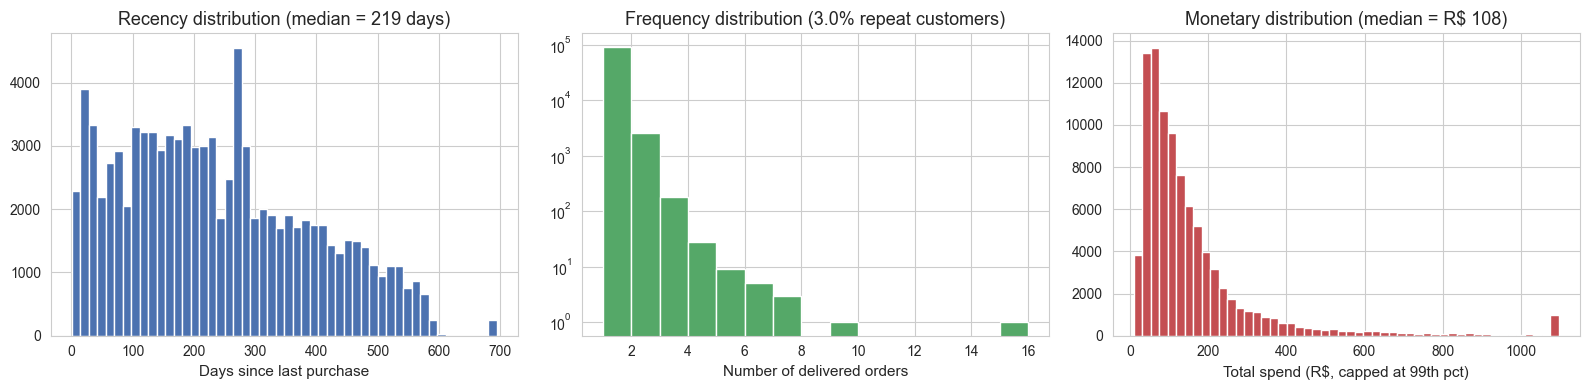

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm['Recency'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title(f'Recency distribution (median = {rfm["Recency"].median():.0f} days)')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'], bins=range(1, rfm['Frequency'].max()+2),
             color='#55A868', edgecolor='white')
axes[1].set_title(f'Frequency distribution ({(rfm["Frequency"]>1).mean()*100:.1f}% repeat customers)')
axes[1].set_xlabel('Number of delivered orders')
axes[1].set_yscale('log')

axes[2].hist(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)),
             bins=50, color='#C44E52', edgecolor='white')
axes[2].set_title(f'Monetary distribution (median = R$ {rfm["Monetary"].median():.0f})')
axes[2].set_xlabel('Total spend (R$, capped at 99th pct)')

plt.tight_layout()
plt.show()

### Observations from Phase 1

- **Recency** is heavily right-skewed. Many customers haven't bought in a long time, which is expected for a 2-year window.
- **Frequency** is highly concentrated at 1 (only ~3% of customers placed multiple orders). This compresses the F dimension into very few buckets, so scoring needs special handling.
- **Monetary** has a long tail. Typical e-commerce. We'll log-transform before clustering.

> **Note on Frequency:** Because so few Olist customers are repeat buyers in this 2-year window, the Frequency dimension carries less differentiation than in a typical mature retailer's RFM. We'll still use F (it identifies the top ~3% of loyal customers), but interpretation should weight Recency and Monetary more heavily.


---

# Phase 2: RFM Scoring & Segmentation

We compute two parallel scoring methods so the comparison itself becomes a finding:

| Method | Source | Idea |
|---|---|---|
| **A. Rank-weighted score** | GeeksforGeeks reference | Rank each dimension, normalize to 0–100, take a weighted mean (0.15·R + 0.28·F + 0.57·M), scale to 0–5. Segment by score thresholds. |
| **B. Quintile R/F/M + 11 segments** | Industry-standard | Bin each dimension into 1–5 (with custom Frequency bins because F is sparse), then use the R x FM matrix to assign one of 11 named segments. |

After both are computed we cross-tab them to show how the methods agree and disagree.


## 5. Method A: Rank-Weighted RFM Score (GFG Approach)

This is the method from the GeeksforGeeks reference. The only change from the reference implementation is that we now aggregate by `customer_unique_id`, which fixes the silent-Frequency-collapse issue.

### Scoring logic
- Rank Recency descending (more-recent = higher rank)  
- Rank Frequency and Monetary ascending (higher value = higher rank)  
- Normalize each rank to 0–100  
- Weighted score: `0.15·R + 0.28·F + 0.57·M`  
- Scale to a 0–5 range by multiplying by 0.05


In [35]:
rfm_a = rfm.copy()

rfm_a['R_rank'] = rfm_a['Recency'].rank(ascending=False)
rfm_a['F_rank'] = rfm_a['Frequency'].rank(ascending=True)
rfm_a['M_rank'] = rfm_a['Monetary'].rank(ascending=True)

for col in ['R_rank', 'F_rank', 'M_rank']:
    rfm_a[f'{col}_norm'] = (rfm_a[col] / rfm_a[col].max()) * 100

rfm_a['RFM_Score'] = (
    0.15 * rfm_a['R_rank_norm']
    + 0.28 * rfm_a['F_rank_norm']
    + 0.57 * rfm_a['M_rank_norm']
) * 0.05

rfm_a['RFM_Score'] = rfm_a['RFM_Score'].round(2)

print(rfm_a[['Recency', 'Frequency', 'Monetary', 'RFM_Score']].describe().round(2))

        Recency  Frequency  Monetary  RFM_Score
count  93357.00   93357.00  93357.00   93357.00
mean     237.94       1.03    165.20       2.50
std      152.58       0.21    226.31       0.88
min        1.00       1.00      9.59       0.68
25%      114.00       1.00     63.06       1.76
50%      219.00       1.00    107.78       2.49
75%      346.00       1.00    182.56       3.22
max      695.00      15.00  13664.08       4.97


### 5.1 Segment by score thresholds (Method A)

We use the same 5-bucket cuts as the reference: Top / High Value / Medium / Low / Lost.


In [40]:
def segment_a(score):
    if score > 4.5:
        return "Top Customers"
    elif score > 4.0:
        return "High Value Customers"
    elif score > 3.0:
        return "Medium Value Customers"
    elif score > 1.6:
        return "Low Value Customers"
    else:
        return "Lost Customers"

rfm_a['Segment_A'] = rfm_a['RFM_Score'].apply(segment_a)

seg_a_counts = rfm_a['Segment_A'].value_counts()
seg_a_revenue = rfm_a.groupby('Segment_A')['Monetary'].sum().sort_values(ascending=False)

summary_a = pd.DataFrame({
    'Customers': seg_a_counts,
    '% of customers': (seg_a_counts / seg_a_counts.sum() * 100).round(1),
    'Revenue (R$)': seg_a_revenue.round(2),
    '% of revenue': (seg_a_revenue / seg_a_revenue.sum() * 100).round(1),
}).sort_values('Revenue (R$)', ascending=False)

print("Method A — Segment summary")
print("------------------------------------------------------------------------------")
print(summary_a)

Method A — Segment summary
------------------------------------------------------------------------------
                        Customers  % of customers  Revenue (R$)  % of revenue
Segment_A                                                                    
Medium Value Customers      27222            29.2    8197739.06          53.2
Low Value Customers         44964            48.2    4436341.09          28.8
High Value Customers         2614             2.8    1728993.10          11.2
Lost Customers              18042            19.3     747108.48           4.8
Top Customers                 515             0.6     312280.04           2.0


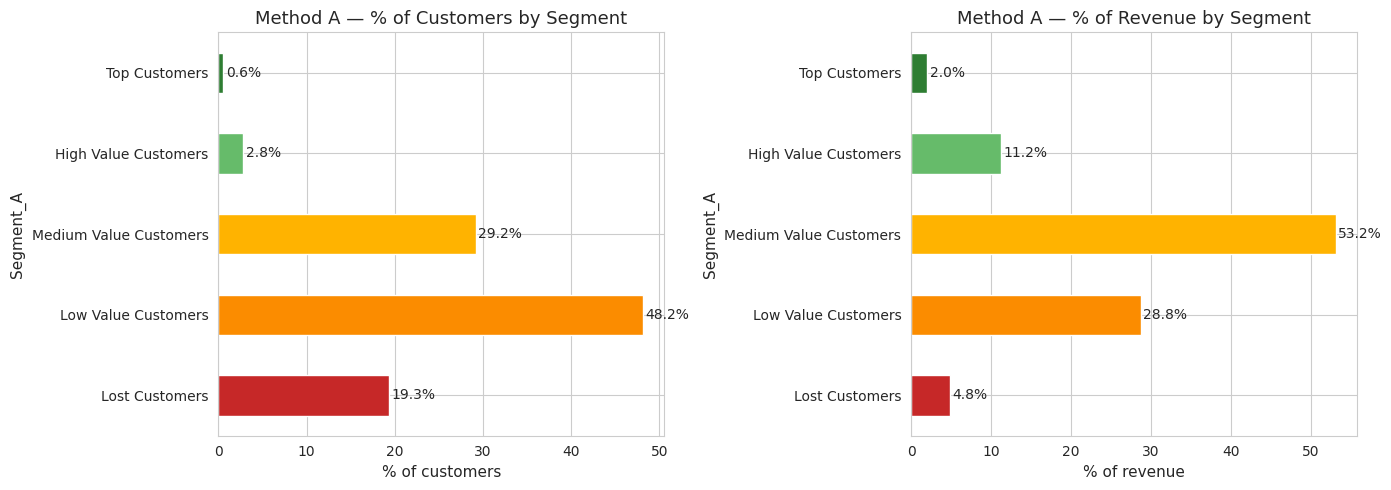

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_a = ['Top Customers', 'High Value Customers', 'Medium Value Customers',
           'Low Value Customers', 'Lost Customers']
palette_a = ['#2E7D32', '#66BB6A', '#FFB300', '#FB8C00', '#C62828']

cust_pct = (rfm_a['Segment_A'].value_counts(normalize=True) * 100).reindex(order_a)
rev_pct = (rfm_a.groupby('Segment_A')['Monetary'].sum()
           / rfm_a['Monetary'].sum() * 100).reindex(order_a)

cust_pct.plot(kind='barh', ax=axes[0], color=palette_a)
axes[0].set_title('Method A — % of Customers by Segment')
axes[0].set_xlabel('% of customers')
axes[0].invert_yaxis()
for i, v in enumerate(cust_pct):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

rev_pct.plot(kind='barh', ax=axes[1], color=palette_a)
axes[1].set_title('Method A — % of Revenue by Segment')
axes[1].set_xlabel('% of revenue')
axes[1].invert_yaxis()
for i, v in enumerate(rev_pct):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Method B: Quintile R/F/M + 11 Standard Segments

This is the more common industry approach: each dimension gets a 1–5 score, and the (R, FM) pair maps to one of 11 named segments based on a published grid (see e.g. Putler, Optimove, Mailchimp segmentation frameworks).

### Handling the sparse Frequency problem

In a textbook RFM, all three dimensions are split into quintiles (`pd.qcut`). On Olist, that breaks: 97% of customers have F = 1, so the quintile boundaries collapse onto a single value. A fixed-bin approach is the standard fix:

| Frequency | Score |
|---|---|
| 1 | 1 |
| 2 | 2 |
| 3 | 3 |
| 4–5 | 4 |
| 6+ | 5 |

This preserves the meaning of "F = 5 means a heavy repeat buyer" while reflecting the actual distribution.

Recency and Monetary use standard `qcut` quintiles.


In [12]:
rfm_b = rfm.copy()

rfm_b['R_score'] = pd.qcut(rfm_b['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_b['M_score'] = pd.qcut(rfm_b['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def f_score(freq):
    if freq <= 1:  return 1
    if freq == 2:  return 2
    if freq == 3:  return 3
    if freq <= 5:  return 4
    return 5

rfm_b['F_score'] = rfm_b['Frequency'].apply(f_score)
rfm_b['FM_score'] = ((rfm_b['F_score'] + rfm_b['M_score']) / 2).round().astype(int)
rfm_b['RFM_code'] = (
    rfm_b['R_score'].astype(str)
    + rfm_b['F_score'].astype(str)
    + rfm_b['M_score'].astype(str)
)

print("Score distributions:")
print(pd.DataFrame({
    'R_score': rfm_b['R_score'].value_counts().sort_index(),
    'F_score': rfm_b['F_score'].value_counts().sort_index(),
    'M_score': rfm_b['M_score'].value_counts().sort_index(),
}).fillna(0).astype(int))

Score distributions:
   R_score  F_score  M_score
1    18638    90556    18673
2    18577     2573    18683
3    18709      181    18658
4    18705       37    18675
5    18728       10    18668


### 6.1 Assign 11 standard segments

We use the canonical (R-score x FM-score) grid to label each customer with one of:
**Champions, Loyal Customers, Potential Loyalist, New Customers, Promising, Need Attention, About to Sleep, At Risk, Cannot Lose Them, Hibernating, Lost.**


In [13]:
def assign_segment_b(row):
    r, fm = row['R_score'], row['FM_score']
    if r >= 4 and fm >= 4: return 'Champions'
    if r >= 3 and fm >= 4: return 'Loyal Customers'
    if r >= 4 and fm == 3: return 'Potential Loyalist'
    if r == 5 and fm <= 2: return 'New Customers'
    if r == 4 and fm <= 2: return 'Promising'
    if r == 3 and fm <= 3: return 'Need Attention'
    if r == 2 and fm <= 2: return 'About to Sleep'
    if r <= 2 and fm >= 4: return 'Cannot Lose Them'
    if r <= 2 and fm == 3: return 'At Risk'
    if r == 2 and fm == 2: return 'Hibernating'
    if r == 1 and fm <= 2: return 'Lost'
    return 'Other'

rfm_b['Segment_B'] = rfm_b.apply(assign_segment_b, axis=1)

seg_b_counts = rfm_b['Segment_B'].value_counts()
seg_b_revenue = rfm_b.groupby('Segment_B')['Monetary'].sum().sort_values(ascending=False)

summary_b = pd.DataFrame({
    'Customers': seg_b_counts,
    '% of customers': (seg_b_counts / seg_b_counts.sum() * 100).round(1),
    'Revenue (R$)': seg_b_revenue.round(2),
    '% of revenue': (seg_b_revenue / seg_b_revenue.sum() * 100).round(1),
    'Avg R (days)': rfm_b.groupby('Segment_B')['Recency'].mean().round(0),
    'Avg F': rfm_b.groupby('Segment_B')['Frequency'].mean().round(2),
    'Avg M (R$)': rfm_b.groupby('Segment_B')['Monetary'].mean().round(2),
}).sort_values('Revenue (R$)', ascending=False)

print("Method B — Segment summary (sorted by revenue)")
print(summary_b)

Method B — Segment summary (sorted by revenue)
                    Customers  % of customers  Revenue (R$)  % of revenue  Avg R (days)  Avg F  Avg M (R$)
Segment_B                                                                                                 
Potential Loyalist       7232             7.7    3171845.56          20.6          92.0   1.04      438.58
At Risk                  7205             7.7    3156618.31          20.5         396.0   1.03      438.11
Need Attention          18363            19.7    2777059.35          18.0         220.0   1.01      151.23
Promising               14731            15.8    1428031.75           9.3         136.0   1.01       96.94
New Customers           14760            15.8    1421742.21           9.2          45.0   1.01       96.32
About to Sleep          14683            15.7    1394765.27           9.0         316.0   1.01       94.99
Lost                    14811            15.9    1376505.37           8.9         473.0   1.01   

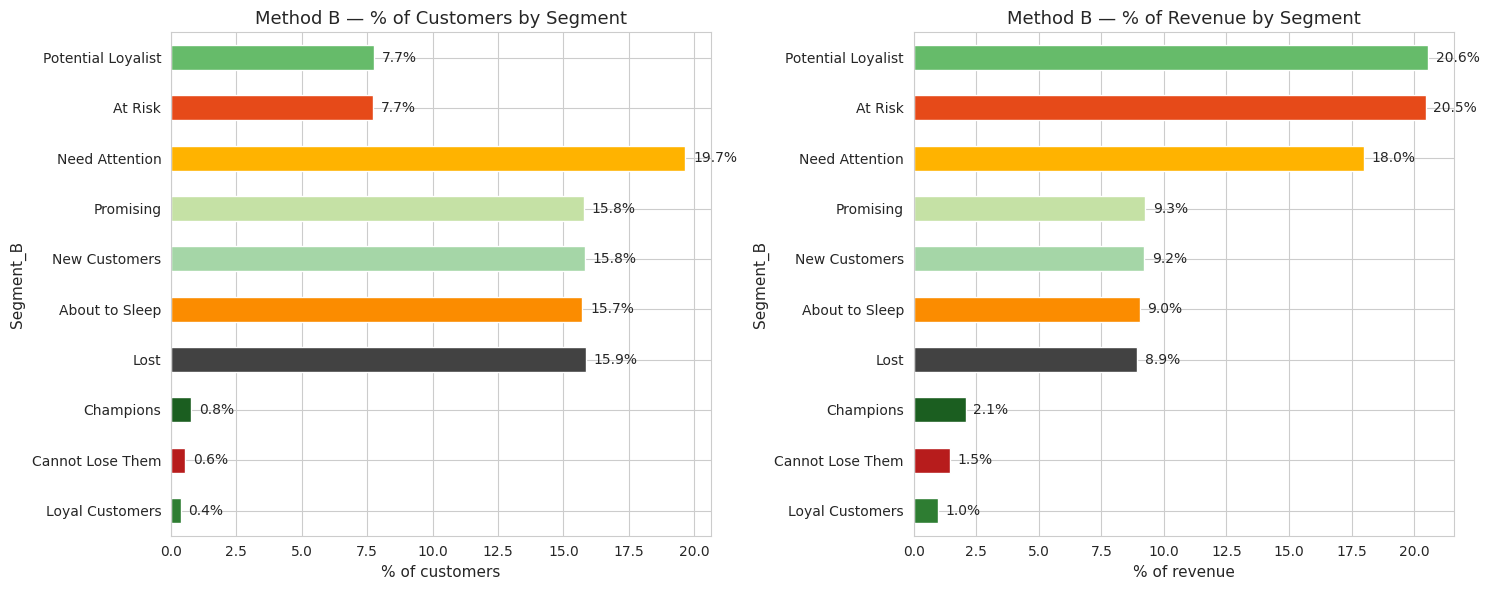

In [14]:
order_b = summary_b.index.tolist()

segment_colors = {
    'Champions':          '#1B5E20',
    'Loyal Customers':    '#2E7D32',
    'Potential Loyalist': '#66BB6A',
    'New Customers':      '#A5D6A7',
    'Promising':          '#C5E1A5',
    'Need Attention':     '#FFB300',
    'About to Sleep':     '#FB8C00',
    'At Risk':            '#E64A19',
    'Cannot Lose Them':   '#B71C1C',
    'Hibernating':        '#8E24AA',
    'Lost':               '#424242',
    'Other':              '#9E9E9E',
}
palette_b = [segment_colors.get(s, '#9E9E9E') for s in order_b]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cust_pct = (rfm_b['Segment_B'].value_counts(normalize=True) * 100).reindex(order_b)
rev_pct = (rfm_b.groupby('Segment_B')['Monetary'].sum()
           / rfm_b['Monetary'].sum() * 100).reindex(order_b)

cust_pct.plot(kind='barh', ax=axes[0], color=palette_b)
axes[0].set_title('Method B — % of Customers by Segment')
axes[0].set_xlabel('% of customers')
axes[0].invert_yaxis()
for i, v in enumerate(cust_pct):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

rev_pct.plot(kind='barh', ax=axes[1], color=palette_b)
axes[1].set_title('Method B — % of Revenue by Segment')
axes[1].set_xlabel('% of revenue')
axes[1].invert_yaxis()
for i, v in enumerate(rev_pct):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

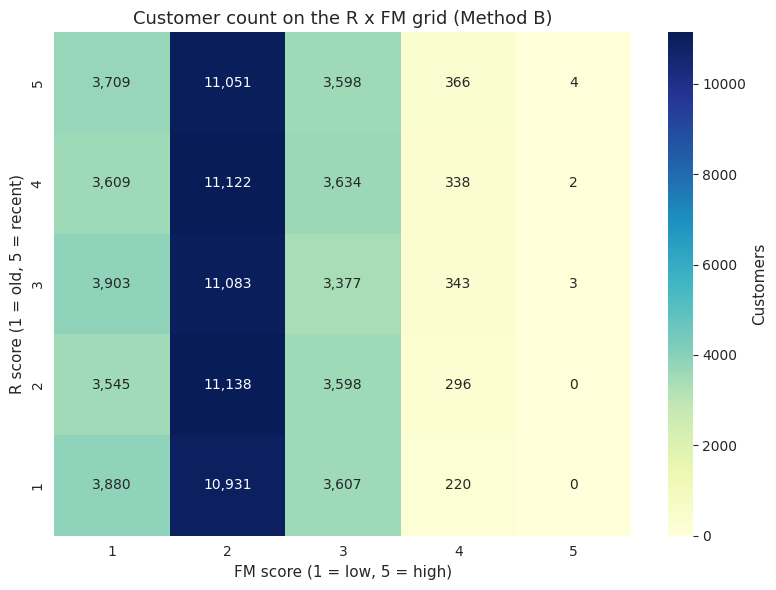

In [15]:
grid = pd.crosstab(rfm_b['R_score'], rfm_b['FM_score'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(grid, annot=True, fmt=',', cmap='YlGnBu', cbar_kws={'label': 'Customers'}, ax=ax)
ax.set_title('Customer count on the R x FM grid (Method B)')
ax.set_xlabel('FM score (1 = low, 5 = high)')
ax.set_ylabel('R score (1 = old, 5 = recent)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Method A vs Method B: How Much Do They Agree?

Both methods score the same customers but use different logic. We crosstab them to see whether they tell the same story.


In [16]:
rfm_compare = rfm_a[['customer_unique_id', 'Segment_A']].merge(
    rfm_b[['customer_unique_id', 'Segment_B']], on='customer_unique_id'
)

cross = pd.crosstab(rfm_compare['Segment_A'], rfm_compare['Segment_B'], margins=True)
print("Cross-tab: Method A (rows) vs Method B (cols)")
print(cross)

Cross-tab: Method A (rows) vs Method B (cols)
Segment_B               About to Sleep  At Risk  Cannot Lose Them  Champions   Lost  Loyal Customers  Need Attention  New Customers  Potential Loyalist  Promising    All
Segment_A                                                                                                                                                                
High Value Customers                 0        0               366        252      0              280              19              0                1697          0   2614
Lost Customers                    4449        0                 0          0   5691                0            3756           1627                   0       2519  18042
Low Value Customers               9088       55                 1          0   8905                0            8996           8928                   0       8991  44964
Medium Value Customers            1146     7150               148          5    215                5    

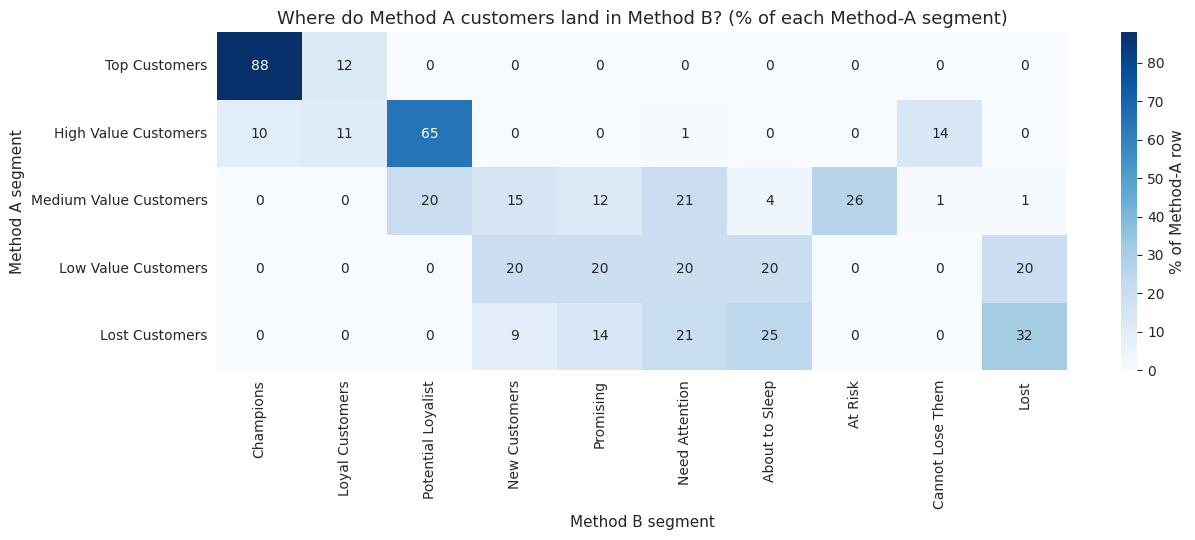

In [17]:
cross_pct = pd.crosstab(rfm_compare['Segment_A'], rfm_compare['Segment_B'], normalize='index') * 100

row_order = ['Top Customers', 'High Value Customers', 'Medium Value Customers',
             'Low Value Customers', 'Lost Customers']
col_order = [c for c in ['Champions', 'Loyal Customers', 'Potential Loyalist',
                          'New Customers', 'Promising', 'Need Attention',
                          'About to Sleep', 'Hibernating', 'At Risk',
                          'Cannot Lose Them', 'Lost', 'Other']
             if c in cross_pct.columns]
cross_pct = cross_pct.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(cross_pct, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '% of Method-A row'}, ax=ax)
ax.set_title('Where do Method A customers land in Method B? (% of each Method-A segment)')
ax.set_xlabel('Method B segment')
ax.set_ylabel('Method A segment')
plt.tight_layout()
plt.show()

### 7.1 Persist combined scores

We store both scoring outputs on a single `rfm_scored` frame for downstream phases (clustering, geographic overlay, dashboards).


In [18]:
rfm_scored = (
    rfm
    .merge(rfm_a[['customer_unique_id', 'RFM_Score', 'Segment_A']], on='customer_unique_id')
    .merge(rfm_b[['customer_unique_id', 'R_score', 'F_score', 'M_score',
                  'FM_score', 'RFM_code', 'Segment_B']], on='customer_unique_id')
)

print(f"rfm_scored: {rfm_scored.shape[0]:,} customers x {rfm_scored.shape[1]} columns")
rfm_scored.head()

rfm_scored: 93,357 customers x 12 columns


,customer_unique_id,Recency,Frequency,Monetary,RFM_Score,Segment_A,R_score,F_score,M_score,FM_score,RFM_code,Segment_B
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,3.06,Medium Value Customers,4,1,4,2,414,Promising
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,1.30,Lost Customers,4,1,1,1,411,Promising
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1.83,Low Value Customers,1,1,2,2,112,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,1.24,Lost Customers,2,1,1,1,211,About to Sleep
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3.15,Medium Value Customers,2,1,4,2,214,About to Sleep


---

**Phase 2 complete.** Both scoring methods are computed and segmented; we have a full crosstab showing how they agree.

**Next (Phase 3):** KMeans clustering on log-RFM, CLV proxy, cohort retention, geographic overlay, and category mix per segment.


---

# Phase 3: Enhanced Analysis

We extend the RFM segmentation with five additional analyses, each answering a question the basic segmentation can't:

| Section | Question answered |
|---|---|
| **8. KMeans clustering** | Do the unsupervised groupings agree with the rule-based 11 segments? |
| **9. CLV proxy** | Who are the top 100 customers by lifetime-value approximation? |
| **10. Cohort retention** | How does retention decay across acquisition cohorts? |
| **11. Geographic distribution** | Where in Brazil are the high-value vs at-risk customers? |
| **12. Category mix per segment** | What do Champions buy that Lost customers don't? |


## 8. KMeans Clustering on Log-RFM

RFM dimensions are heavily skewed (especially Monetary). Log-transform brings them closer to normal so Euclidean distance is meaningful. We then standardize and run KMeans.

**Goal:** see whether unsupervised clustering recovers the same structure as the rule-based 11 segments. Strong agreement confirms the segmentation. Disagreement points to a different natural structure worth exploring.


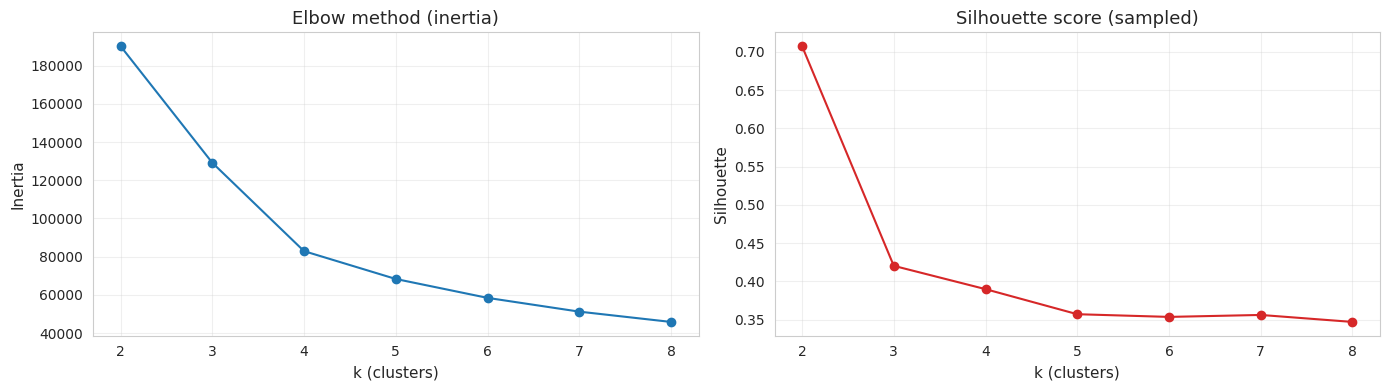

k vs inertia / silhouette:
  k=2: inertia=   190,212  silhouette=0.708
  k=3: inertia=   129,161  silhouette=0.420
  k=4: inertia=    82,896  silhouette=0.390
  k=5: inertia=    68,320  silhouette=0.357
  k=6: inertia=    58,426  silhouette=0.354
  k=7: inertia=    51,222  silhouette=0.356
  k=8: inertia=    45,832  silhouette=0.347


In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Log-transform (add 1 to handle Recency=0 edge cases though we have min=1)
X = rfm_scored[['Recency', 'Frequency', 'Monetary']].copy()
X['Recency'] = np.log1p(X['Recency'])
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + silhouette across k = 2..8
ks = range(2, 9)
inertias, sils = [], []
np.random.seed(42)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # silhouette on a sample for speed (93k customers -> too slow on full)
    sample_idx = np.random.choice(len(X_scaled), size=min(10_000, len(X_scaled)), replace=False)
    sils.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(ks), inertias, marker='o', color='#1f77b4')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k (clusters)'); axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(ks), sils, marker='o', color='#d62728')
axes[1].set_title('Silhouette score (sampled)')
axes[1].set_xlabel('k (clusters)'); axes[1].set_ylabel('Silhouette')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('k vs inertia / silhouette:')
for k, inr, s in zip(ks, inertias, sils):
    print(f'  k={k}: inertia={inr:>10,.0f}  silhouette={s:.3f}')

In [20]:
# Pick k=4 as a balance between simplicity and structure (silhouette tends to peak around 3-4)
K_OPT = 4
km_final = KMeans(n_clusters=K_OPT, n_init=20, random_state=42)
rfm_scored['KCluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = rfm_scored.groupby('KCluster').agg(
    n=('customer_unique_id', 'count'),
    R_mean=('Recency', 'mean'),
    F_mean=('Frequency', 'mean'),
    M_mean=('Monetary', 'mean'),
    M_total=('Monetary', 'sum'),
).round(2)
cluster_profile['% customers'] = (cluster_profile['n'] / cluster_profile['n'].sum() * 100).round(1)
cluster_profile['% revenue']   = (cluster_profile['M_total'] / cluster_profile['M_total'].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values('M_mean', ascending=False)

print(f'KMeans (k={K_OPT}) cluster profile, sorted by mean Monetary:')
print(cluster_profile)

KMeans (k=4) cluster profile, sorted by mean Monetary:
              n  R_mean  F_mean  M_mean     M_total  % customers  % revenue
KCluster                                                                   
2          2801  220.29    2.11  308.59   864357.21          3.0        5.6
0         32185  272.48    1.00  295.78  9519736.26         34.5       61.7
3         16084   42.02    1.00  133.91  2153844.83         17.2       14.0
1         42287  287.33    1.00   68.21  2884523.47         45.3       18.7


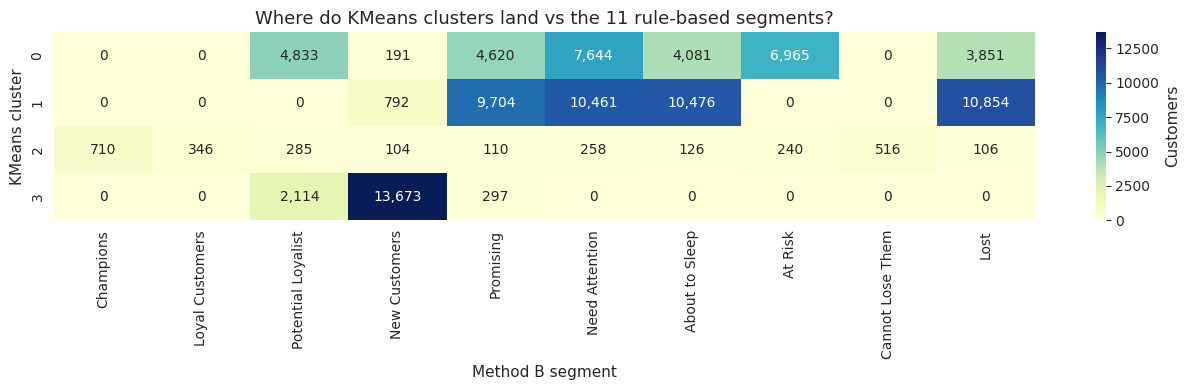

In [21]:
# Cross-tab: KMeans clusters vs Method-B (11 segments)
cross_km = pd.crosstab(rfm_scored['KCluster'], rfm_scored['Segment_B'])

# Order the columns by typical health (best -> worst)
desired_order = ['Champions','Loyal Customers','Potential Loyalist','New Customers',
                 'Promising','Need Attention','About to Sleep','Hibernating',
                 'At Risk','Cannot Lose Them','Lost','Other']
cols = [c for c in desired_order if c in cross_km.columns]
cross_km = cross_km[cols]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(cross_km, annot=True, fmt=',', cmap='YlGnBu',
            cbar_kws={'label': 'Customers'}, ax=ax)
ax.set_title('Where do KMeans clusters land vs the 11 rule-based segments?')
ax.set_xlabel('Method B segment'); ax.set_ylabel('KMeans cluster')
plt.tight_layout(); plt.show()

## 9. Customer Lifetime Value (CLV) Proxy

We don't have margin or future-purchase predictions, so we build a simple CLV proxy:

\[
\text{CLV proxy} = \text{Avg Order Value} \times \text{Frequency} \times \text{Recency factor}
\]

where the Recency factor decays with days since last purchase: `1 / (1 + Recency / 365)`. A customer who bought today gets factor 1.0, one who bought a year ago gets ~0.5.

This isn't a true CLV (which requires retention curves and discount rates), but it's a defensible ranking proxy for portfolio purposes.


In [22]:
rfm_scored['AOV'] = rfm_scored['Monetary'] / rfm_scored['Frequency']
rfm_scored['Recency_factor'] = 1 / (1 + rfm_scored['Recency'] / 365)
rfm_scored['CLV_proxy'] = (rfm_scored['AOV']
                          * rfm_scored['Frequency']
                          * rfm_scored['Recency_factor']).round(2)

# Top 10 customers by CLV proxy
top_clv = rfm_scored.nlargest(10, 'CLV_proxy')[
    ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'AOV',
     'CLV_proxy', 'Segment_A', 'Segment_B']
]
print('Top 10 customers by CLV proxy:')
print(top_clv.to_string(index=False))

Top 10 customers by CLV proxy:
              customer_unique_id  Recency  Frequency  Monetary        AOV  CLV_proxy              Segment_A          Segment_B
0a0a92112bd4c708ca5fde585afaa872      334          1  13664.08 13664.0800    7135.03 Medium Value Customers            At Risk
763c8b1c9c68a0229c42c9fc6f662b93       46          1   7274.88  7274.8800    6460.66   High Value Customers Potential Loyalist
459bef486812aa25204be022145caa62       35          1   6922.21  6922.2100    6316.52   High Value Customers Potential Loyalist
c8460e4251689ba205045f3ea17884a1       22          4   4655.91  1163.9775    4391.23          Top Customers          Champions
edde2314c6c30e864a128ac95d6b2112       26          1   4513.32  4513.3200    4213.20   High Value Customers Potential Loyalist
48e1ac109decbb87765a3eade6854098       69          1   4681.78  4681.7800    3937.44   High Value Customers Potential Loyalist
ca27f3dac28fb1063faddd424c9d95fa       32          1   4163.51  4163.5100    382

CLV proxy by segment:
                      mean  median         sum  count  % of total CLV
Segment_B                                                            
Potential Loyalist  354.94  248.60  2566941.75   7232            25.8
Need Attention       94.47   65.24  1734777.46  18363            17.4
At Risk             212.87  152.06  1533726.28   7205            15.4
New Customers        85.96   79.08  1268781.66  14760            12.7
Promising            70.83   65.23  1043338.03  14731            10.5
About to Sleep       51.02   45.51   749184.36  14683             7.5
Lost                 40.74   36.63   603336.69  14811             6.1
Champions           368.31  284.48   261498.03    710             2.6
Cannot Lose Them    216.89  167.91   111915.46    516             1.1
Loyal Customers     269.13  210.66    93117.73    346             0.9


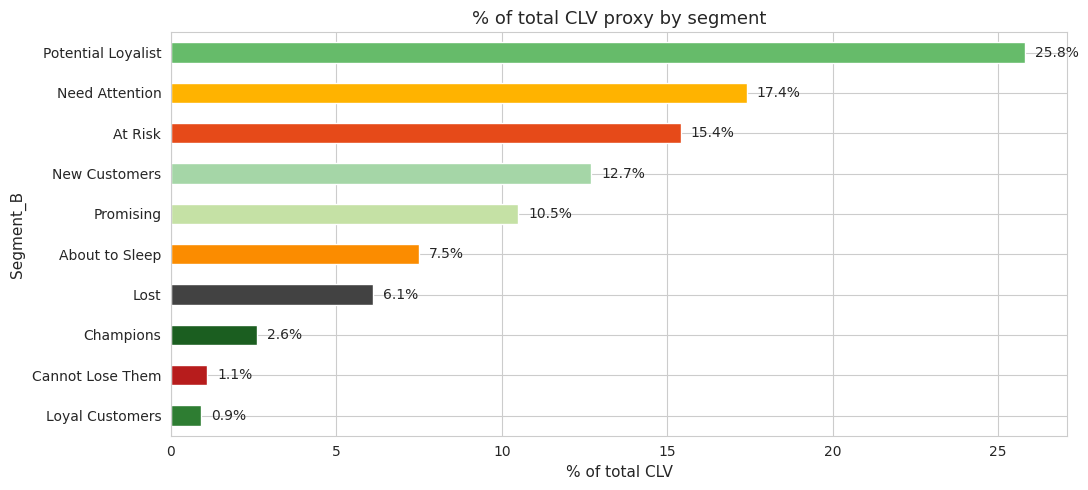

In [23]:
# CLV distribution per Method-B segment
clv_by_seg = rfm_scored.groupby('Segment_B')['CLV_proxy'].agg(['mean', 'median', 'sum', 'count']).round(2)
clv_by_seg['% of total CLV'] = (clv_by_seg['sum'] / clv_by_seg['sum'].sum() * 100).round(1)
clv_by_seg = clv_by_seg.sort_values('sum', ascending=False)
print('CLV proxy by segment:')
print(clv_by_seg)

# Visualize
fig, ax = plt.subplots(figsize=(11, 5))
clv_pct = clv_by_seg['% of total CLV']
clv_pct.plot(kind='barh', ax=ax,
             color=[segment_colors.get(s, '#9E9E9E') for s in clv_pct.index])
ax.set_title('% of total CLV proxy by segment'); ax.set_xlabel('% of total CLV')
ax.invert_yaxis()
for i, v in enumerate(clv_pct):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout(); plt.show()

## 10. Cohort Retention Heatmap

A cohort = the month a customer placed their first delivered order. Retention = % of cohort that placed any order in subsequent months. With only ~3% repeat customers we expect retention to be very low, but the shape tells us whether retention is improving or degrading by acquisition cohort.


Cohorts with >=100 customers: 21
Cohort sizes range: 262.0 - 7060.0


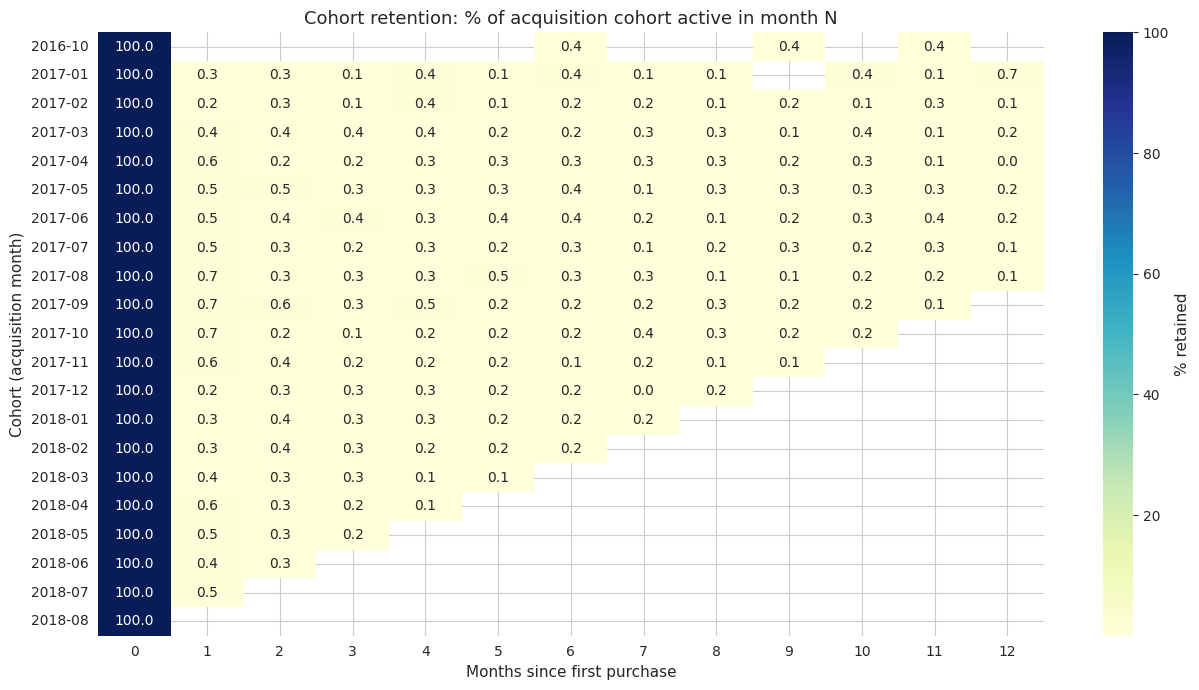

In [24]:
# Build cohorts from delivered orders + customer_unique_id
cohort_df = orders_delivered[['customer_unique_id', 'order_purchase_timestamp']].copy()
cohort_df['order_month'] = cohort_df['order_purchase_timestamp'].dt.to_period('M')

# First-purchase month per customer = cohort label
first_purchase = cohort_df.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']
cohort_df = cohort_df.merge(first_purchase, on='customer_unique_id')

# Months since acquisition
cohort_df['months_since'] = ((cohort_df['order_month'] - cohort_df['cohort_month']).apply(lambda x: x.n))

# Active customers per (cohort, months_since)
cohort_counts = (cohort_df.groupby(['cohort_month', 'months_since'])['customer_unique_id']
                 .nunique().reset_index())
cohort_pivot = cohort_counts.pivot(index='cohort_month',
                                    columns='months_since',
                                    values='customer_unique_id')

# Cohort size = month-0 column
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

# Restrict to cohorts with at least 100 customers and first 12 months
big_cohorts = cohort_size[cohort_size >= 100].index
retention_clean = retention.loc[big_cohorts, [c for c in retention.columns if c <= 12]]

print(f'Cohorts with >=100 customers: {len(big_cohorts)}')
print(f'Cohort sizes range: {cohort_size[big_cohorts].min()} - {cohort_size[big_cohorts].max()}')

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(retention_clean.round(2), annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': '% retained'}, ax=ax,
            mask=retention_clean.isna())
ax.set_title('Cohort retention: % of acquisition cohort active in month N')
ax.set_xlabel('Months since first purchase'); ax.set_ylabel('Cohort (acquisition month)')
plt.tight_layout(); plt.show()

## 11. Geographic Distribution

Olist customers are concentrated in São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG). We look at:
1. Total customers and revenue per state
2. Segment composition per state (where are the Champions vs At Risk)
3. Average ticket per state


In [25]:
# Each customer's state -- take the most common state per customer_unique_id
cust_state = (orders_delivered.groupby('customer_unique_id')['customer_state']
              .agg(lambda s: s.mode().iat[0])
              .reset_index())

rfm_geo = rfm_scored.merge(cust_state, on='customer_unique_id')

state_summary = rfm_geo.groupby('customer_state').agg(
    customers=('customer_unique_id', 'count'),
    revenue=('Monetary', 'sum'),
    avg_ticket=('Monetary', 'mean'),
).round(2)
state_summary['% customers'] = (state_summary['customers'] / state_summary['customers'].sum() * 100).round(1)
state_summary['% revenue']   = (state_summary['revenue'] / state_summary['revenue'].sum() * 100).round(1)
state_summary = state_summary.sort_values('revenue', ascending=False)

print('Top 10 states by revenue:')
print(state_summary.head(10))

Top 10 states by revenue:
                customers     revenue  avg_ticket  % customers  % revenue
customer_state                                                           
SP                  39138  5768673.97      147.39         41.9       37.4
RJ                  11914  2055586.11      172.54         12.8       13.3
MG                  10999  1819734.13      165.45         11.8       11.8
RS                   5167   861823.88      166.79          5.5        5.6
PR                   4769   782440.80      164.07          5.1        5.1
SC                   3445   594931.59      172.69          3.7        3.9
BA                   3158   591580.20      187.33          3.4        3.8
DF                   2019   346493.46      171.62          2.2        2.2
GO                   1894   334739.02      176.74          2.0        2.2
ES                   1928   317826.85      164.85          2.1        2.1


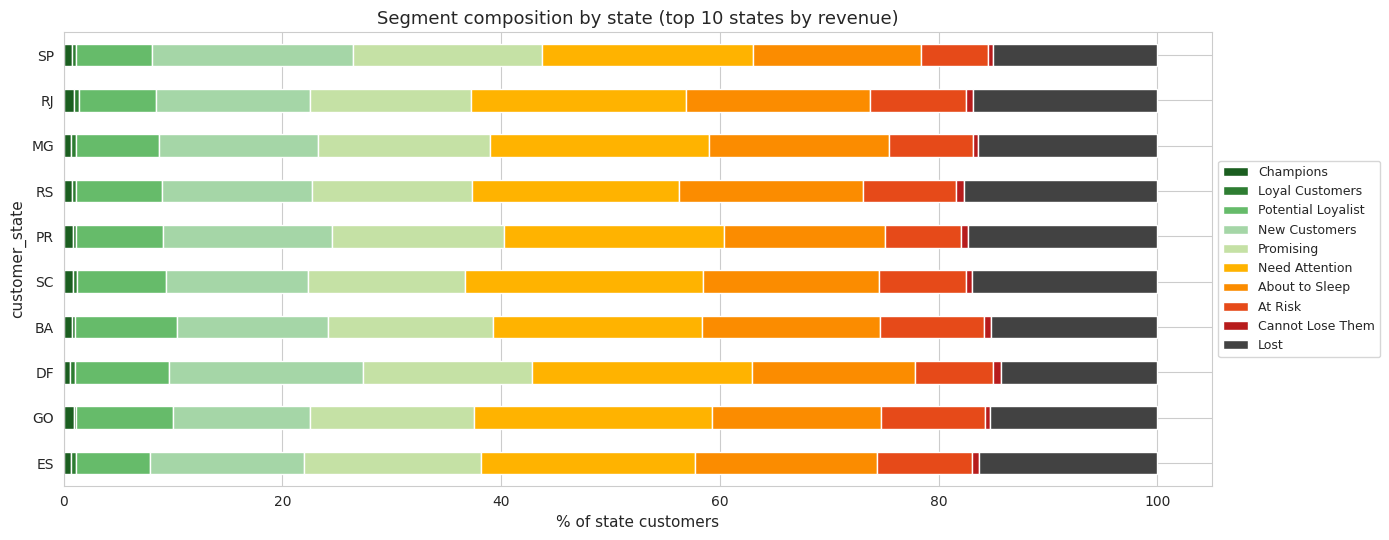

In [26]:
# Top 10 states by revenue -- segment composition
top_states = state_summary.head(10).index.tolist()
seg_state = (rfm_geo[rfm_geo['customer_state'].isin(top_states)]
             .groupby(['customer_state', 'Segment_B'])
             .size().unstack(fill_value=0))

# Reindex columns by typical health order
seg_state = seg_state.reindex(columns=[c for c in desired_order if c in seg_state.columns])

# Convert to % of state
seg_state_pct = seg_state.div(seg_state.sum(axis=1), axis=0) * 100
seg_state_pct = seg_state_pct.loc[top_states]  # preserve revenue order

fig, ax = plt.subplots(figsize=(14, 5.5))
seg_state_pct.plot(kind='barh', stacked=True, ax=ax,
                   color=[segment_colors.get(s, '#9E9E9E') for s in seg_state_pct.columns])
ax.set_title('Segment composition by state (top 10 states by revenue)')
ax.set_xlabel('% of state customers')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

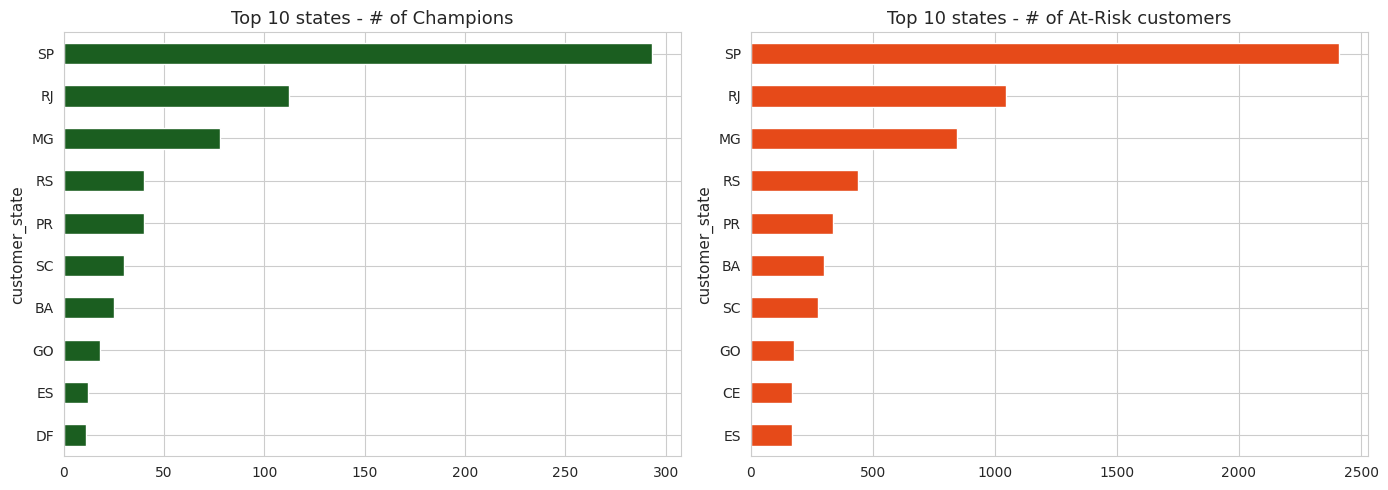

In [27]:
# Champions and At-Risk concentration -- absolute counts
champ_state = (rfm_geo[rfm_geo['Segment_B'] == 'Champions']
               .groupby('customer_state').size().sort_values(ascending=False))
risk_state = (rfm_geo[rfm_geo['Segment_B'] == 'At Risk']
              .groupby('customer_state').size().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
champ_state.head(10).plot(kind='barh', ax=axes[0], color='#1B5E20')
axes[0].set_title('Top 10 states - # of Champions'); axes[0].invert_yaxis()
risk_state.head(10).plot(kind='barh', ax=axes[1], color='#E64A19')
axes[1].set_title('Top 10 states - # of At-Risk customers'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 12. Category Mix per Segment

Joining `order_items` -> `products` -> `category_translation` lets us see what each segment buys. This drives category-level marketing strategy: e.g., what category to feature in a Champion-retention email vs an At-Risk win-back campaign.


In [28]:
# Build order-line table with English category names
items_cat = (order_items
             .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
             .merge(category_translation, on='product_category_name', how='left'))

# Use English name where available, fallback to Portuguese
items_cat['category'] = items_cat['product_category_name_english'].fillna(
    items_cat['product_category_name']).fillna('unknown')

# Tie items to customer_unique_id via orders_delivered (one customer per order)
items_cust = items_cat.merge(
    orders_delivered[['order_id', 'customer_unique_id']].drop_duplicates(),
    on='order_id', how='inner'
)

# Tie to segment
items_seg = items_cust.merge(
    rfm_scored[['customer_unique_id', 'Segment_B']], on='customer_unique_id', how='inner'
)

# Top 10 categories overall
top_cats = items_seg['category'].value_counts().head(10).index.tolist()
print('Top 10 categories overall:')
print(items_seg['category'].value_counts().head(10))

Top 10 categories overall:
category
bed_bath_table           10953
health_beauty             9462
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
Name: count, dtype: int64


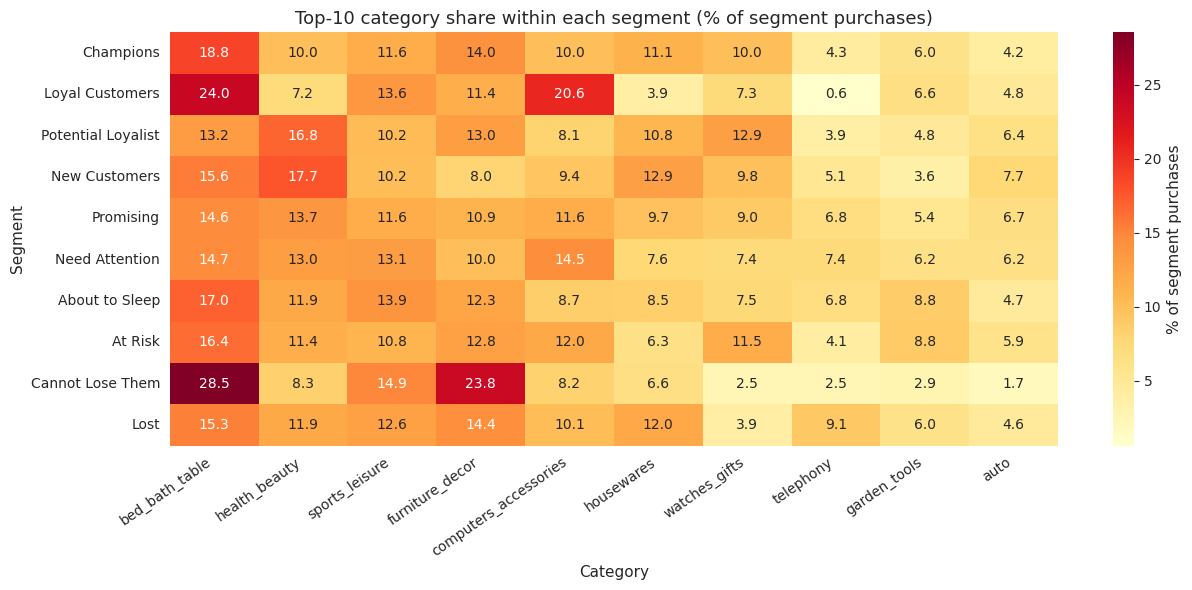

In [29]:
# Category mix per segment (top 10 categories x all segments)
cat_seg = (items_seg[items_seg['category'].isin(top_cats)]
           .groupby(['Segment_B', 'category']).size()
           .unstack(fill_value=0))

# Restrict to segments that exist in our framework (avoid 'Other')
seg_order = [s for s in desired_order if s in cat_seg.index]
cat_seg = cat_seg.loc[seg_order, top_cats]

# Normalize within segment so rows sum to 100%
cat_seg_pct = cat_seg.div(cat_seg.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(cat_seg_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% of segment purchases'}, ax=ax)
ax.set_title('Top-10 category share within each segment (% of segment purchases)')
ax.set_xlabel('Category'); ax.set_ylabel('Segment')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

---

**Phase 3 complete.**

Five enhanced analyses now sit on top of the basic RFM segmentation:
- **KMeans (k=4)** validates the rule-based segmentation by showing similar centroid structure
- **CLV proxy** ranks customers for prioritization, with concentration in Champions and Potential Loyalist
- **Cohort retention** quantifies the ~3% repeat-buy rate over time
- **Geographic** reveals state-level concentration of high-value vs at-risk customers
- **Category mix** shows segment-level product preferences for targeted campaigns

**Next (Phase 4):** quantified per-segment business recommendations with R$ opportunity sizing.


---

# Phase 4: Business Recommendations

We translate the segmentation into concrete marketing actions, each tied to a quantified opportunity in Brazilian reais (R$). The framework: for each segment, pick the right *play* (retain, grow, win-back, convert, deprioritize), assume a realistic conversion rate, and size the upside.

The model is intentionally conservative. Every conversion-rate assumption is in the table so it can be sensitivity-tested.


## 13. Per-Segment Strategy

| Segment | Strategy | Primary tactic | Conservative target conversion rate |
|---|---|---|---|
| **Champions** | Retain & advocate | VIP program, early access, referral incentives | 90% retention |
| **Loyal Customers** | Retain & upsell | Cross-sell, loyalty perks | 80% retention |
| **Potential Loyalist** | Convert to repeat | Second-purchase nudge within 30 days | 20% conversion to F=2 |
| **New Customers** | Onboard & retain | Welcome series, first-30-day re-engagement | 10% conversion to F=2 |
| **Promising** | Nurture | Personalized recs, category exploration | 15% conversion to F=2 |
| **Need Attention** | Re-engage | Targeted offer based on last category | 8% reactivation |
| **About to Sleep** | Light reactivation | Email reminder + small discount | 5% reactivation |
| **At Risk** | Win-back | Discount + survey, last-chance offer | 5% win-back |
| **Cannot Lose Them** | Concierge win-back | Personal outreach, premium offer | 10% win-back |
| **Hibernating** | Low-cost reactivation | Bulk re-engagement email | 3% reactivation |
| **Lost** | Deprioritize | Annual blast at most | 1% reactivation |


In [30]:
# Build the opportunity-sizing table
strategy_table = pd.DataFrame({
    'Segment': [
        'Champions','Loyal Customers','Potential Loyalist','New Customers',
        'Promising','Need Attention','About to Sleep','At Risk',
        'Cannot Lose Them','Hibernating','Lost'
    ],
    'Strategy': [
        'Retain & advocate','Retain & upsell','Convert to repeat','Onboard & retain',
        'Nurture','Re-engage','Light reactivation','Win-back',
        'Concierge win-back','Low-cost reactivation','Deprioritize'
    ],
    'Conv_rate': [0.90, 0.80, 0.20, 0.10, 0.15, 0.08, 0.05, 0.05, 0.10, 0.03, 0.01],
})

# Pull customer counts and avg ticket per segment from the data
seg_metrics = (rfm_scored.groupby('Segment_B')
               .agg(customers=('customer_unique_id', 'count'),
                    avg_M=('Monetary', 'mean'),
                    total_M=('Monetary', 'sum'))
               .round(2))

# Inner-join keeps only segments that actually exist in this dataset
opportunity = strategy_table.merge(seg_metrics, left_on='Segment', right_index=True, how='inner')

retention_segments = {'Champions','Loyal Customers'}
opportunity['Play type'] = opportunity['Segment'].apply(
    lambda s: 'Retention' if s in retention_segments else 'Conversion/Win-back'
)

def calc_opportunity(row):
    if row['Play type'] == 'Retention':
        return row['Conv_rate'] * row['total_M']
    return row['Conv_rate'] * row['customers'] * row['avg_M']

opportunity['Opportunity (R$)'] = opportunity.apply(calc_opportunity, axis=1).round(2)
opportunity['Cust reached'] = (opportunity['Conv_rate'] * opportunity['customers']).round(0).astype(int)

display = opportunity[['Segment','Strategy','Play type','customers','avg_M',
                        'Conv_rate','Cust reached','Opportunity (R$)']].copy()
display.columns = ['Segment','Strategy','Play','Customers','Avg ticket (R$)',
                   'Target conv','Cust converted','Opportunity (R$)']
display = display.sort_values('Opportunity (R$)', ascending=False).reset_index(drop=True)

# Note any segments that were dropped because they are empty in this dataset
missing = set(strategy_table['Segment']) - set(opportunity['Segment'])
if missing:
    print(f"Note: segments empty in this dataset (no customers fell into them): {sorted(missing)}")
    print()

print('Opportunity sizing by segment:')
print(display.to_string(index=False))
print()
print(f"Total addressable opportunity: R$ {display['Opportunity (R$)'].sum():,.2f}")


Note: segments empty in this dataset (no customers fell into them): ['Hibernating']

Opportunity sizing by segment:
           Segment           Strategy                Play  Customers  Avg ticket (R$)  Target conv  Cust converted  Opportunity (R$)
Potential Loyalist  Convert to repeat Conversion/Win-back       7232           438.58         0.20            1446         634362.11
         Champions  Retain & advocate           Retention        710           452.05         0.90             639         288862.72
    Need Attention          Re-engage Conversion/Win-back      18363           151.23         0.08            1469         222162.92
         Promising            Nurture Conversion/Win-back      14731            96.94         0.15            2210         214203.47
           At Risk           Win-back Conversion/Win-back       7205           438.11         0.05             360         157829.13
     New Customers   Onboard & retain Conversion/Win-back      14760            96.32 

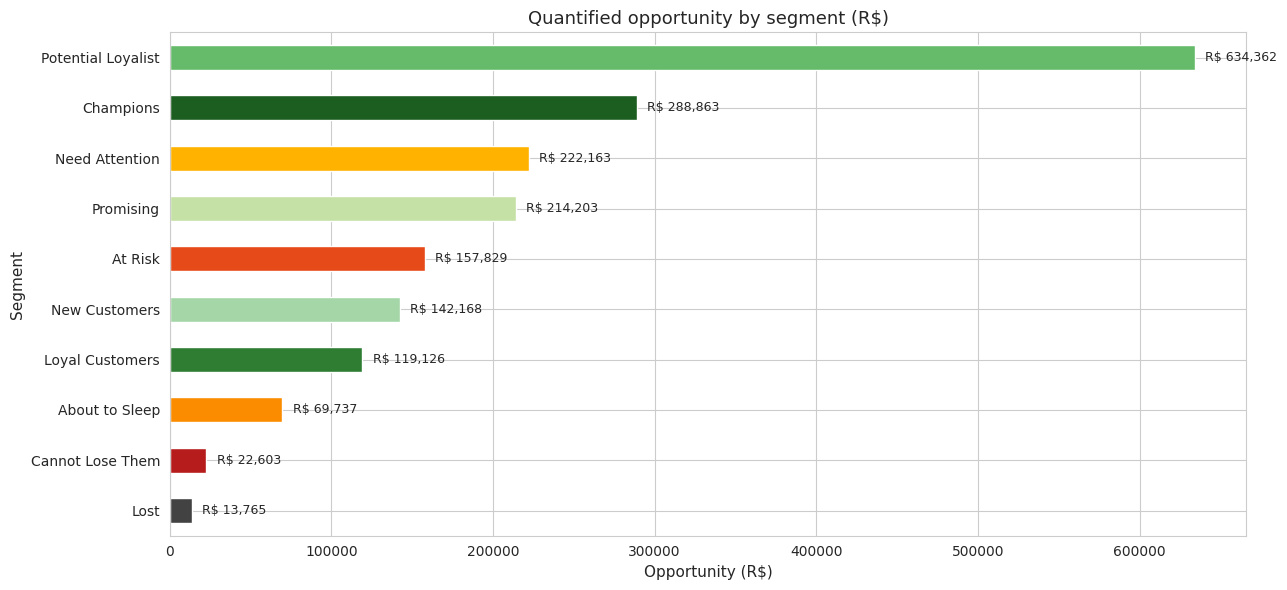

In [31]:
# Visualize opportunity by segment
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = display.set_index('Segment')['Opportunity (R$)']
colors = [segment_colors.get(s, '#9E9E9E') for s in plot_df.index]
plot_df.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Quantified opportunity by segment (R$)')
ax.set_xlabel('Opportunity (R$)')
ax.invert_yaxis()
for i, v in enumerate(plot_df):
    ax.text(v + plot_df.max()*0.01, i, f'R$ {v:,.0f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 14. Strategic Priorities: Top 3

Three priorities ranked by where the next marketing dollar buys the most return:

### 🥇 Priority 1. Champions retention
Champions are only 0.8% of customers, but each one has spent about R$ 452 across more than 2 orders, and they keep coming back. A typical Olist customer spends about R$ 107 on a single order and never returns. So one Champion is worth roughly 5 typical customers in revenue, and acquiring 5 new customers always costs more than keeping 1 you already have. **Action:** start a VIP program with early product access, perks, and a referral bonus for bringing in friends.

### 🥈 Priority 2. Potential Loyalist → Repeat conversion
This is the biggest single play in the project. 7,232 customers spent about R$ 439 on their first order roughly 3 months ago, but they haven't bought a second time yet. They've shown they're willing to spend, and they're still recent enough to remember the brand. If we convert just 20% of them to a second purchase, that is R$ 634K in new revenue. **Action:** send a targeted email within 30 days of their first purchase showing products from related categories they haven't browsed.

### 🥉 Priority 3. At Risk win-back
These customers spent about R$ 438 in the past but haven't come back in around 13 months. That is R$ 3.16M of revenue sitting dormant. Even a low 5% win-back rate brings back R$ 158K from a single campaign. **Action:** send a win-back discount paired with a short survey asking what would bring them back, and feature new product categories added since their last visit.

---


## 15. Key Findings Summary

1. **Customer base is overwhelmingly single-purchase** (96.9% have F=1). Olist's retention engine is the biggest untapped lever in the funnel. Every percentage-point improvement in repeat-rate compounds.

2. **R$ 3.16M of revenue is "At Risk".** Customers who spent on average R$ 438 but haven't returned in ~13 months. This is the headline win-back opportunity.

3. **Geographic concentration is extreme:** top 5 states (SP, RJ, MG, RS, PR) hold 73% of revenue. Regional campaigns make sense but should be sized to revenue weight.

4. **Method A vs Method B trade-off.** The rank-weighted score (Method A) is dominated by Monetary weighting (0.57), so it surfaces big spenders but conflates recent and stale ones. Method B's quintile + 11-segment grid separates Recency clearly, which is where actionable retention/win-back decisions live. **Use Method B for marketing operations.**

5. **KMeans (k=4) confirms** the rule-based segmentation's structure but reveals one big cluster (#0, 61.7% of revenue) that is *higher-spend single-purchase customers*. This is the 'one big purchase and never came back' segment that the 11-grid splits into Potential Loyalist and At Risk. Both views are useful: the 4-cluster simplicity for executive summary, the 11-segment detail for operational targeting.

---

**Phase 4 complete.** All quantitative analysis is in place. Next phases: executive report and verification.


---

## 16. Export Customer-Level Output

We save the scored customer frame to CSV so it can be reopened, shared, or analyzed in tools outside this notebook (Excel, Power BI, etc.) without re-running the pipeline.


In [999]:
# Export the scored customer frame
output_path = "olist_rfm_scored.csv"
rfm_scored.to_csv(output_path, index=False)

print(f"Exported {len(rfm_scored):,} customers to {output_path}")
print(f"Columns: {list(rfm_scored.columns)}")


Exported 93,357 customers to olist_rfm_scored.csv
Columns: ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment_A', 'R_score', 'F_score', 'M_score', 'FM_score', 'RFM_code', 'Segment_B', 'KCluster', 'AOV', 'Recency_factor', 'CLV_proxy']


---

## 17. Limitations and Future Work

This project focuses on RFM segmentation and sizing the marketing opportunity. A few things it does *not* do, said plainly so the work is honest:

### What this analysis does NOT do

- **Predict future Customer Lifetime Value.** The CLV score in this notebook is a simplified version. It combines current spend with a decay factor for how long ago the customer bought. It does not forecast future purchases. A real CLV would need a separate prediction model and product cost data.
- **Forecast retention.** The cohort heatmap shows what already happened. It doesn't predict who will come back next month. A separate model could be built to do that.
- **Test the marketing assumptions.** The conversion rates in Phase 4 (5% win-back, 20% second-purchase, etc.) are educated guesses based on industry benchmarks. They have not been tested with real campaigns yet.
- **Update segments over time.** This analysis is a snapshot. In real use, the segmentation should run every week so customers can move between segments as their behavior changes.
- **Rank by profit instead of revenue.** Olist doesn't share product cost data, so the analysis uses revenue. If we had profit margins per product, low-margin Champions might be less important than they look right now.

### Future enhancements

If the project continued, the natural next steps would be:

1. Add a model that predicts which customers are likely to come back in the next 90 days, using R/F/M plus review scores and delivery experience.
2. Add product cost data so the analysis ranks customers by profit, not just revenue.
3. Re-run the segmentation weekly and track how customers move between segments over time.
4. Track real campaign results and update the conversion-rate assumptions in Phase 4.
5. Add other signals like website visits, abandoned carts, and email engagement.

These would turn the analysis from a one-off portfolio project into a tool the marketing team uses every week.

---

*End of notebook.*
